In [2]:
import csv
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [3]:
# df_final

In [4]:
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

df_final = pd.concat([df_train, df_test], ignore_index=True)

In [5]:
bin_edges = np.arange(15, 55, 5)
df_final['BMICALC'] = df_final['BMICALC'].clip(lower=15.01, upper =50)
df_final['bmi_bin'] = pd.cut(df_final['BMICALC'], bins=bin_edges)

# get % of diseased in each bin
grouped_diab_final  = df_final.groupby('bmi_bin', observed=True)['DIABETICEV'].apply(lambda x: (x == 2).mean() * 100)
grouped_hyper_final = df_final.groupby('bmi_bin', observed=True)['HYPERTENEV'].apply(lambda x: (x == 2).mean() * 100)

# assign each sample weight
df_final['diab_risk'] = df_final['bmi_bin'].map(grouped_diab_final)
df_final['hyper_risk'] = df_final['bmi_bin'].map(grouped_hyper_final)

# normalize to get probabilites
df_final['diab_risk'] = df_final['diab_risk'].astype(float) / sum(grouped_diab_final.values)
df_final['hyper_risk'] = df_final['hyper_risk'].astype(float) / sum(grouped_hyper_final.values)

In [6]:
# df_hypertension

In [7]:
df_hyper =  pd.read_csv('thesis__data_res.csv', usecols=['YEAR', 'BMICALC', 'HYPERTENEV'])

In [8]:
# clean df
df_hyper = df_hyper[(df_hyper['HYPERTENEV'] == 1) | (df_hyper['HYPERTENEV']==2)]

# only samples that are in 15-50 bmi range so we can make plot
df_hyper = df_hyper[(df_hyper['BMICALC'] > 15) | (df_hyper['BMICALC'] <= 50)]
# select years
df_hyper_1990 = df_hyper[(df_hyper['YEAR'] == 1989) | (df_hyper['YEAR'] == 1990) | (df_hyper['YEAR'] == 1991)]

print(f"people with hypertension: ", len(df_hyper[(df_hyper['HYPERTENEV'] == 2)]) / len(df_hyper) *100, "%")

people with hypertension:  28.900713016294453 %


In [9]:
df_hyper_1990 = df_hyper_1990.copy()
df_hyper_1990.loc[:,'bmi_bin'] = pd.cut(df_hyper_1990['BMICALC'], bins=bin_edges)
# get % of diseased in each bin
grouped_hyper_1990 = df_hyper_1990.groupby('bmi_bin', observed=True)['HYPERTENEV'].apply(lambda x: (x == 2).mean() * 100)

In [10]:
# df_diabetic

In [11]:
df_diab =  pd.read_csv('thesis__data_res.csv', usecols=['YEAR', 'BMICALC', 'DIABETICEV'])

In [12]:
# clean df
df_diab = df_diab[(df_diab['DIABETICEV'] == 1) | (df_diab['DIABETICEV']==2)]

# only samples that are in 15-50 bmi range so we can make plot
df_diab = df_diab[(df_diab['BMICALC'] > 15) | (df_diab['BMICALC'] <= 50)]
# select years
df_diab_1990 = df_diab[(df_diab['YEAR'] == 1989) | (df_diab['YEAR'] == 1990) | (df_diab['YEAR'] == 1993)]

In [13]:
print(f"people wiht diabetes: ", len(df_diab[(df_diab['DIABETICEV'] == 2)]) / len(df_diab) *100, "%")

people wiht diabetes:  5.910809933884034 %


In [14]:
df_diab_1990 = df_diab_1990.copy()
df_diab_1990.loc[:,'bmi_bin'] = pd.cut(df_diab_1990['BMICALC'], bins=bin_edges)
# get % of diseased in each bin
grouped_diab_1990 = df_diab_1990.groupby('bmi_bin', observed=True)['DIABETICEV'].apply(lambda x: (x == 2).mean() * 100)

In [15]:
# --- plot----

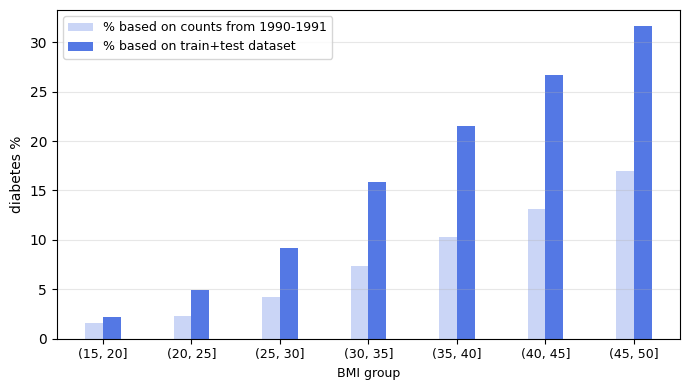

In [16]:
labels = grouped_diab_1990.index
x = np.arange(len(labels)) 
width = 0.2  

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x - width/2, grouped_diab_1990.values, width, label='% based on counts from 1990-1991',  color='royalblue', alpha=0.28)
bar2 = ax.bar(x + width/2, grouped_diab_final.values, width, label='% based on train+test dataset', color='royalblue', alpha=0.9)

ax.set_xlabel('BMI group',fontsize=9)
ax.set_ylabel('diabetes %', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0,fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.savefig('T_diab.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

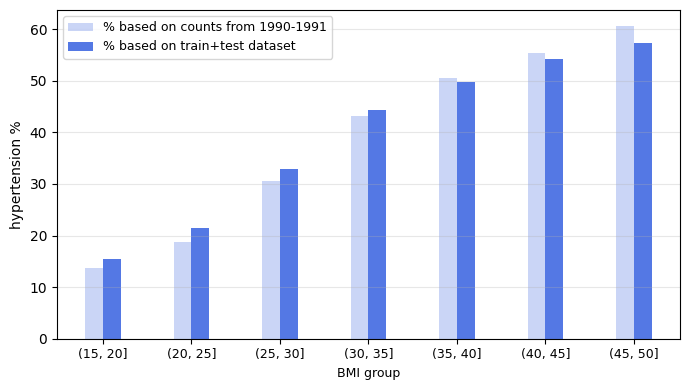

In [17]:
labels = grouped_diab_1990.index
x = np.arange(len(labels))
width = 0.2 

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x - width/2, grouped_hyper_1990.values, width, label='% based on counts from 1990-1991',  color='royalblue', alpha=0.28)
bar2 = ax.bar(x + width/2, grouped_hyper_final.values, width, label='% based on train+test dataset', color='royalblue', alpha=0.9)

ax.set_xlabel('BMI group', fontsize=9)
ax.set_ylabel('hypertension %', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.savefig('T_hyper.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# --- get c ---

In [19]:
# calculate c's
c_hyper = 103400 * len(df_final[df_final['HYPERTENEV']==2]) / len(df_final) -  103400 * len(df_hyper_1990[df_hyper_1990['HYPERTENEV']==2]) / len(df_hyper_1990)
c_diab = 103400 * len(df_final[df_final['DIABETICEV']==2]) / len(df_final) -  103400 * len(df_diab_1990[df_diab_1990['DIABETICEV']==2]) / len(df_diab_1990)

In [20]:
def weighted_sample(df, feature, weights_column, c):
    np.random.seed(22)

    # filter only diseased rows
    selected_rows = df[df[feature] == 2]
    
    # define inverse of risk as weights (so that skinny people are more likely to be recoded as healhty)
    weights = 1/selected_rows[weights_column]
    weights = np.asarray(weights)
    weights = weights / weights.sum()  

    # perform weighted sampling
    selected_indices = np.random.choice(selected_rows.index, size=c, replace=False, p=weights)

    return df.loc[selected_indices]

In [21]:
# selected at (weighted) random indivdiuals to make healthy
selected_people_diab = list(weighted_sample(df_final, 'DIABETICEV', 'diab_risk', round(c_diab)).index)
selected_people_hyper = list(weighted_sample(df_final, 'HYPERTENEV', 'hyper_risk', round(c_hyper)).index)

In [22]:
# save list of individulas to make healt
with open('selected_people_hyper.pkl', 'wb') as f:
    pickle.dump(selected_people_hyper, f)
# save list of individulas to make healthy
with open('selected_people_diab.pkl', 'wb') as f:
    pickle.dump(selected_people_diab, f)